<a href="https://colab.research.google.com/github/nattyix/ML-LAB/blob/main/MLLab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.stats import mode
import matplotlib.pyplot as plt
from  sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [ ]:
iris  = load_iris()
x = iris.data
y = iris.target

In [ ]:
print(x.shape)

kmeans = KMeans(n_clusters = 3, random_state = 0)
k_labels = kmeans.fit_predict(x)

gmm = GaussianMixture(n_components = 3, random_state = 0)
g_labels = gmm.fit_predict(x)

(150, 4)


In [ ]:
def match_labels(true_labels, predicted_labels):
  matched = np.zeros_like(true_labels)
  for i in range(3):
    mask = predicted_labels == i
    matched[mask] = mode(true_labels[mask], keepdims=True).mode[0]
  return matched

In [ ]:
kmeans_accuracy = accuracy_score(y, match_labels(y, k_labels))
gmm_accuracy = accuracy_score(y, match_labels(y, g_labels))
print("K-Means Accuracy: ", kmeans_accuracy)
print("GMM Accuracy: ", gmm_accuracy)

K-Means Accuracy:  0.8866666666666667
GMM Accuracy:  0.9666666666666667


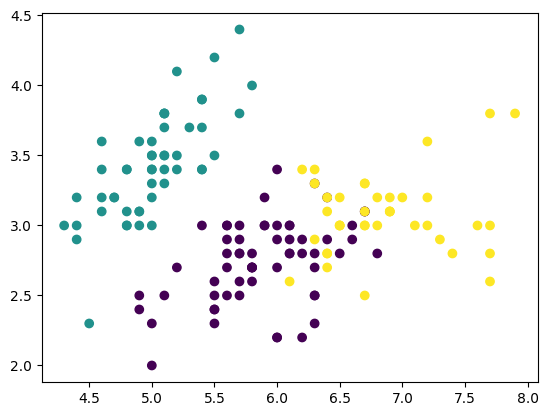

In [ ]:
plt.scatter(x[:,0], x[:,1], c = k_labels)
plt.show()

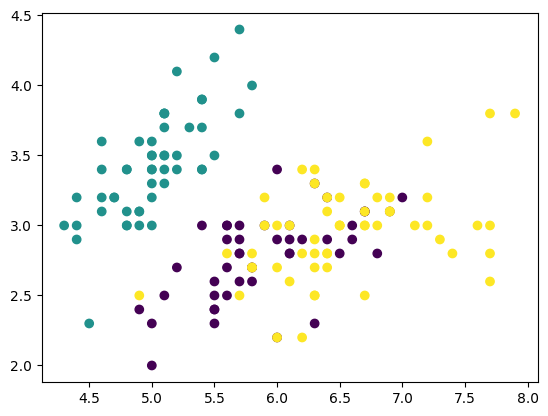

In [ ]:
plt.scatter(x[:,0], x[:,1], c = g_labels)
plt.show()